In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.rc('font',family='Malgun Gothic' )
!pip install koreanize-matplotlib
from IPython.display import display
import koreanize_matplotlib
import seaborn as sns


In [353]:
origin_train=pd.read_csv("data/train.csv")
origin_test=pd.read_csv("data/test.csv")
data_train=origin_train.copy()
data_test=origin_test.copy()


In [354]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [355]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [356]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8040 non-null   object 
 1   Rented Bike Count          8040 non-null   int64  
 2   Hour                       8040 non-null   int64  
 3   Temperature(째C)            7240 non-null   float64
 4   Humidity(%)                8040 non-null   int64  
 5   Wind speed (m/s)           7238 non-null   float64
 6   Visibility (10m)           8040 non-null   int64  
 7   Dew point temperature(째C)  8040 non-null   float64
 8   Solar Radiation (MJ/m2)    8040 non-null   float64
 9   Rainfall(mm)               8040 non-null   float64
 10  Snowfall (cm)              8040 non-null   float64
 11  Seasons                    7238 non-null   object 
 12  Holiday                    8040 non-null   object 
 13  Functioning Day            8040 non-null   objec

In [357]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       720 non-null    object 
 1   Hour                       720 non-null    int64  
 2   Temperature(째C)            644 non-null    float64
 3   Humidity(%)                720 non-null    int64  
 4   Wind speed (m/s)           646 non-null    float64
 5   Visibility (10m)           720 non-null    int64  
 6   Dew point temperature(째C)  720 non-null    float64
 7   Solar Radiation (MJ/m2)    720 non-null    float64
 8   Rainfall(mm)               720 non-null    float64
 9   Snowfall (cm)              720 non-null    float64
 10  Seasons                    646 non-null    object 
 11  Holiday                    720 non-null    object 
 12  Functioning Day            720 non-null    object 
dtypes: float64(6), int64(3), object(4)
memory usage: 7

In [358]:
data_train.isnull().sum()

Date                           0
Rented Bike Count              0
Hour                           0
Temperature(째C)              800
Humidity(%)                    0
Wind speed (m/s)             802
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Seasons                      802
Holiday                        0
Functioning Day                0
dtype: int64

In [359]:
data_test.isnull().sum()

Date                          0
Hour                          0
Temperature(째C)              76
Humidity(%)                   0
Wind speed (m/s)             74
Visibility (10m)              0
Dew point temperature(째C)     0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                      74
Holiday                       0
Functioning Day               0
dtype: int64

In [360]:
data_train[data_train['Seasons'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,NaN,No Holiday,Yes
20,01/12/2017,426,20,-0.3,79,1.5,1913,-3.5,0.00,0.0,0.0,NaN,No Holiday,Yes
31,02/12/2017,146,7,-4.4,81,2.5,1276,-7.1,0.00,0.0,0.0,NaN,No Holiday,Yes
32,02/12/2017,219,8,-4.2,79,2.1,1436,-7.3,0.01,0.0,0.0,NaN,No Holiday,Yes
36,02/12/2017,479,12,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,NaN,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,30/10/2018,182,3,1.7,59,0.5,2000,-5.4,0.00,0.0,0.0,NaN,No Holiday,Yes
7998,30/10/2018,394,6,0.8,69,1.4,2000,-4.2,0.00,0.0,0.0,NaN,No Holiday,Yes
8014,30/10/2018,948,22,7.6,50,1.8,2000,-2.1,0.00,0.0,0.0,NaN,No Holiday,Yes
8030,31/10/2018,963,14,11.9,34,2.4,1835,-3.4,2.12,0.0,0.0,NaN,No Holiday,Yes


In [361]:
data_train[data_train['Date'] == '01/06/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
4368,01/06/2018,963,0,NaN,63,NaN,1698,12.8,0.00,0.0,0.0,Summer,No Holiday,Yes
4369,01/06/2018,776,1,19.5,65,NaN,1662,12.7,0.00,0.0,0.0,Summer,No Holiday,Yes
4370,01/06/2018,554,2,19.0,72,1.4,1258,13.8,0.00,0.0,0.0,NaN,No Holiday,Yes
4371,01/06/2018,366,3,18.6,72,1.4,1340,13.4,0.00,0.0,0.0,Summer,No Holiday,Yes
4372,01/06/2018,265,4,18.1,76,1.8,561,13.7,0.00,0.0,0.0,NaN,No Holiday,Yes
4373,01/06/2018,306,5,17.8,75,1.0,1210,13.3,0.00,0.0,0.0,Summer,No Holiday,Yes
4374,01/06/2018,672,6,17.5,76,1.2,1161,13.2,0.05,0.0,0.0,Summer,No Holiday,Yes
4375,01/06/2018,1421,7,18.1,64,0.6,923,11.1,0.47,0.0,0.0,Summer,No Holiday,Yes
4376,01/06/2018,2149,8,20.6,55,0.7,1200,11.2,1.21,0.0,0.0,Summer,No Holiday,Yes
4377,01/06/2018,1219,9,23.1,52,1.7,1012,12.6,1.88,0.0,0.0,NaN,No Holiday,Yes


In [362]:
data_train[data_train['Date'] == '01/09/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6576,01/09/2018,1075,0,23.2,83,0.5,1887,20.1,0.00,0.0,0.0,Autumn,No Holiday,Yes
6577,01/09/2018,975,1,22.7,83,0.1,1940,19.6,0.00,0.0,0.0,Autumn,No Holiday,Yes
6578,01/09/2018,785,2,22.0,86,0.4,1703,19.5,0.00,0.0,0.0,Autumn,No Holiday,Yes
6579,01/09/2018,514,3,21.6,87,NaN,1579,19.3,0.00,0.0,0.0,Autumn,No Holiday,Yes
6580,01/09/2018,338,4,21.2,88,0.9,1183,19.1,0.00,0.0,0.0,Autumn,No Holiday,Yes
6581,01/09/2018,260,5,21.1,87,0.6,1116,18.8,0.00,0.0,0.0,NaN,No Holiday,Yes
6582,01/09/2018,362,6,20.9,87,0.7,1198,18.6,0.00,0.0,0.0,Autumn,No Holiday,Yes
6583,01/09/2018,511,7,21.1,81,1.0,1738,17.7,0.14,0.0,0.0,Autumn,No Holiday,Yes
6584,01/09/2018,812,8,22.3,64,1.7,2000,15.1,0.75,0.0,0.0,Autumn,No Holiday,Yes
6585,01/09/2018,925,9,24.1,56,2.1,1956,14.7,1.46,0.0,0.0,Autumn,No Holiday,Yes


In [363]:
data_train[data_train['Date'] == '31/08/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6552,31/08/2018,861,0,23.9,75,1.7,1192,19.1,0.00,0.0,0.0,Summer,No Holiday,Yes
6553,31/08/2018,652,1,23.7,77,1.1,1099,19.4,0.00,0.0,0.0,Summer,No Holiday,Yes
6554,31/08/2018,381,2,23.4,79,0.4,1045,19.5,0.00,0.0,0.0,Summer,No Holiday,Yes
6555,31/08/2018,297,3,23.3,81,1.7,1068,19.8,0.00,0.0,0.0,NaN,No Holiday,Yes
6556,31/08/2018,170,4,23.2,83,1.6,1102,20.1,0.00,0.0,0.0,Summer,No Holiday,Yes
6557,31/08/2018,217,5,23.1,84,NaN,1022,20.2,0.00,0.0,0.0,Summer,No Holiday,Yes
6558,31/08/2018,436,6,22.9,83,0.0,1239,19.8,0.00,0.0,0.0,Summer,No Holiday,Yes
6559,31/08/2018,828,7,22.9,83,0.6,1127,19.8,0.01,0.0,0.0,NaN,No Holiday,Yes
6560,31/08/2018,1686,8,23.1,80,0.2,1066,19.4,0.27,0.1,0.0,Summer,No Holiday,Yes
6561,31/08/2018,1049,9,24.1,69,0.9,1662,18.0,0.76,0.0,0.0,Summer,No Holiday,Yes


In [364]:
data_train[data_train['Date'] == '01/03/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
2160,01/03/2018,71,0,2.0,96,1.3,1894,1.4,0.00,2.0,0.0,Spring,Holiday,Yes
2161,01/03/2018,147,1,2.1,97,0.2,859,1.6,0.00,0.0,0.0,Spring,Holiday,Yes
2162,01/03/2018,180,2,2.0,97,1.0,580,1.5,0.00,0.0,0.0,Spring,Holiday,Yes
2163,01/03/2018,92,3,1.6,97,2.3,469,1.1,0.00,0.1,0.0,Spring,Holiday,Yes
2164,01/03/2018,28,4,1.6,97,1.1,636,1.1,0.00,0.0,0.0,Spring,Holiday,Yes
2165,01/03/2018,11,5,2.2,97,2.9,362,1.7,0.00,0.0,0.0,Spring,Holiday,Yes
2166,01/03/2018,33,6,3.0,96,2.7,303,2.4,0.00,0.4,0.0,Spring,Holiday,Yes
2167,01/03/2018,61,7,2.6,89,4.3,320,0.9,0.00,0.0,0.0,Spring,Holiday,Yes
2168,01/03/2018,148,8,1.5,80,3.2,1246,-1.5,0.04,0.0,0.0,Spring,Holiday,Yes
2169,01/03/2018,160,9,0.1,78,4.9,615,-3.2,0.09,0.0,0.0,Spring,Holiday,Yes


In [365]:
data_train[data_train['Date'] == '28/02/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
2136,28/02/2018,266,0,5.1,52,1.1,614,-3.9,0.00,0.0,0.0,Winter,No Holiday,Yes
2137,28/02/2018,229,1,5.0,53,1.4,557,-3.8,0.00,0.0,0.0,Winter,No Holiday,Yes
2138,28/02/2018,174,2,5.2,54,1.3,516,-3.3,0.00,0.0,0.0,NaN,No Holiday,Yes
2139,28/02/2018,116,3,5.3,55,1.7,488,-3.0,0.00,0.0,0.0,NaN,No Holiday,Yes
2140,28/02/2018,72,4,5.4,56,1.7,472,-2.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2141,28/02/2018,62,5,5.2,59,1.7,437,-2.1,0.00,0.0,0.0,Winter,No Holiday,Yes
2142,28/02/2018,165,6,5.2,60,1.9,430,-1.9,0.00,0.0,0.0,Winter,No Holiday,Yes
2143,28/02/2018,426,7,NaN,59,2.8,448,-1.8,0.00,0.0,0.0,Winter,No Holiday,Yes
2144,28/02/2018,816,8,5.7,57,2.5,458,-2.1,0.04,0.0,0.0,Winter,No Holiday,Yes
2145,28/02/2018,419,9,6.2,55,2.4,478,-2.1,0.13,0.0,0.0,Winter,No Holiday,Yes


In [366]:
# 12~2월은 겨울, 3~5월은 봄, 6~8월은 여름, 9~11월은 가을

In [367]:
data_train1 = data_train.copy()

In [368]:
data_train1

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [369]:
data_train1['Date'] = pd.to_datetime(data_train1['Date'], format='%d/%m/%Y')
start_date1 = pd.to_datetime('01/12/2017', format='%d/%m/%Y')
end_date1 = pd.to_datetime('28/02/2018', format='%d/%m/%Y')

In [370]:
data_train1.loc[data_train1['Date'].between(start_date1, end_date1), 'Seasons'] = 'Winter'

In [371]:
data_train1[data_train1['Date'] == '28/02/2018']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
2136,2018-02-28,266,0,5.1,52,1.1,614,-3.9,0.00,0.0,0.0,Winter,No Holiday,Yes
2137,2018-02-28,229,1,5.0,53,1.4,557,-3.8,0.00,0.0,0.0,Winter,No Holiday,Yes
2138,2018-02-28,174,2,5.2,54,1.3,516,-3.3,0.00,0.0,0.0,Winter,No Holiday,Yes
2139,2018-02-28,116,3,5.3,55,1.7,488,-3.0,0.00,0.0,0.0,Winter,No Holiday,Yes
2140,2018-02-28,72,4,5.4,56,1.7,472,-2.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2141,2018-02-28,62,5,5.2,59,1.7,437,-2.1,0.00,0.0,0.0,Winter,No Holiday,Yes
2142,2018-02-28,165,6,5.2,60,1.9,430,-1.9,0.00,0.0,0.0,Winter,No Holiday,Yes
2143,2018-02-28,426,7,NaN,59,2.8,448,-1.8,0.00,0.0,0.0,Winter,No Holiday,Yes
2144,2018-02-28,816,8,5.7,57,2.5,458,-2.1,0.04,0.0,0.0,Winter,No Holiday,Yes
2145,2018-02-28,419,9,6.2,55,2.4,478,-2.1,0.13,0.0,0.0,Winter,No Holiday,Yes


In [372]:
start_date2 = pd.to_datetime('01/03/2018', format='%d/%m/%Y')
end_date2 = pd.to_datetime('31/05/2018', format='%d/%m/%Y')
data_train1.loc[data_train1['Date'].between(start_date2, end_date2), 'Seasons'] = 'Spring'

In [373]:
start_date3 = pd.to_datetime('01/06/2018', format='%d/%m/%Y')
end_date3 = pd.to_datetime('31/08/2018', format='%d/%m/%Y')
data_train1.loc[data_train1['Date'].between(start_date3, end_date3), 'Seasons'] = 'Summer'

In [374]:
start_date4 = pd.to_datetime('01/09/2018', format='%d/%m/%Y')
end_date4 = pd.to_datetime('31/10/2018', format='%d/%m/%Y')
data_train1.loc[data_train1['Date'].between(start_date4, end_date4), 'Seasons'] = 'Autumn'

In [375]:
data_train[data_train['Seasons'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,NaN,No Holiday,Yes
20,01/12/2017,426,20,-0.3,79,1.5,1913,-3.5,0.00,0.0,0.0,NaN,No Holiday,Yes
31,02/12/2017,146,7,-4.4,81,2.5,1276,-7.1,0.00,0.0,0.0,NaN,No Holiday,Yes
32,02/12/2017,219,8,-4.2,79,2.1,1436,-7.3,0.01,0.0,0.0,NaN,No Holiday,Yes
36,02/12/2017,479,12,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,NaN,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,30/10/2018,182,3,1.7,59,0.5,2000,-5.4,0.00,0.0,0.0,NaN,No Holiday,Yes
7998,30/10/2018,394,6,0.8,69,1.4,2000,-4.2,0.00,0.0,0.0,NaN,No Holiday,Yes
8014,30/10/2018,948,22,7.6,50,1.8,2000,-2.1,0.00,0.0,0.0,NaN,No Holiday,Yes
8030,31/10/2018,963,14,11.9,34,2.4,1835,-3.4,2.12,0.0,0.0,NaN,No Holiday,Yes


In [376]:
data_train1[data_train1['Seasons'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [377]:
data_train1[data_train1['Temperature(째C)'].isnull()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6,2017-12-01,181,6,NaN,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01,930,8,NaN,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
21,2017-12-01,405,21,NaN,81,0.8,1687,-3.6,0.00,0.0,0.0,Winter,No Holiday,Yes
22,2017-12-01,398,22,NaN,83,1.5,1380,-3.4,0.00,0.0,0.0,Winter,No Holiday,Yes
23,2017-12-01,323,23,NaN,84,NaN,1265,-3.6,0.00,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8021,2018-10-31,141,5,NaN,74,NaN,2000,-0.1,0.00,0.0,0.0,Autumn,No Holiday,Yes
8025,2018-10-31,996,9,NaN,56,1.8,1825,-2.9,0.89,0.0,0.0,Autumn,No Holiday,Yes
8027,2018-10-31,818,11,NaN,41,2.6,1907,-3.8,1.96,0.0,0.0,Autumn,No Holiday,Yes
8031,2018-10-31,994,15,NaN,35,NaN,1908,-3.0,1.72,0.0,0.0,Autumn,No Holiday,Yes


In [378]:
data_train1[:24]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,NaN,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,2017-12-01,181,6,NaN,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01,930,8,NaN,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [379]:
data_train1.loc[4, 'Wind speed (m/s)'] = 2.3

In [380]:
data_train1[:24]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,2017-12-01,181,6,NaN,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01,930,8,NaN,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [381]:
data_train1.loc[6, 'Temperature(째C)'] = -6.6
data_train1.loc[8, 'Temperature(째C)'] = -7.6

In [382]:
data_train1[:24]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,2017-12-01,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [383]:
new_data = pd.read_csv('data/train_obs.csv', encoding='cp949')
new_data

,지점,지점명,일시,기온(°C),풍속(m/s),이슬점온도(°C)
0,108,서울,2017-12-01 00:00,-5.2,2.2,-17.6
1,108,서울,2017-12-01 01:00,-5.5,0.8,-17.6
2,108,서울,2017-12-01 02:00,-6.0,1.0,-17.7
3,108,서울,2017-12-01 03:00,-6.2,0.9,-17.6
4,108,서울,2017-12-01 04:00,-6.0,2.3,-18.6
...,...,...,...,...,...,...
8035,108,서울,2018-10-31 19:00,8.4,1.0,-0.6
8036,108,서울,2018-10-31 20:00,7.6,0.7,0.0
8037,108,서울,2018-10-31 21:00,7.6,3.0,0.0
8038,108,서울,2018-10-31 22:00,6.8,2.2,-0.9


In [384]:
new_data['일시'] = pd.to_datetime(new_data['일시'])

In [385]:
new_data['Date'] = new_data['일시'].dt.normalize()

In [386]:
new_data['Hour'] = new_data['일시'].dt.hour

In [387]:
new_data

,지점,지점명,일시,기온(°C),풍속(m/s),이슬점온도(°C),Date,Hour
0,108,서울,2017-12-01 00:00:00,-5.2,2.2,-17.6,2017-12-01,0
1,108,서울,2017-12-01 01:00:00,-5.5,0.8,-17.6,2017-12-01,1
2,108,서울,2017-12-01 02:00:00,-6.0,1.0,-17.7,2017-12-01,2
3,108,서울,2017-12-01 03:00:00,-6.2,0.9,-17.6,2017-12-01,3
4,108,서울,2017-12-01 04:00:00,-6.0,2.3,-18.6,2017-12-01,4
...,...,...,...,...,...,...,...,...
8035,108,서울,2018-10-31 19:00:00,8.4,1.0,-0.6,2018-10-31,19
8036,108,서울,2018-10-31 20:00:00,7.6,0.7,0.0,2018-10-31,20
8037,108,서울,2018-10-31 21:00:00,7.6,3.0,0.0,2018-10-31,21
8038,108,서울,2018-10-31 22:00:00,6.8,2.2,-0.9,2018-10-31,22


In [388]:
new_data = new_data.rename(columns={
    '기온(°C)': 'Temperature(째C)', 
    '풍속(m/s)': 'Wind speed (m/s)'
})

In [389]:
new_data

,지점,지점명,일시,Temperature(째C),Wind speed (m/s),이슬점온도(°C),Date,Hour
0,108,서울,2017-12-01 00:00:00,-5.2,2.2,-17.6,2017-12-01,0
1,108,서울,2017-12-01 01:00:00,-5.5,0.8,-17.6,2017-12-01,1
2,108,서울,2017-12-01 02:00:00,-6.0,1.0,-17.7,2017-12-01,2
3,108,서울,2017-12-01 03:00:00,-6.2,0.9,-17.6,2017-12-01,3
4,108,서울,2017-12-01 04:00:00,-6.0,2.3,-18.6,2017-12-01,4
...,...,...,...,...,...,...,...,...
8035,108,서울,2018-10-31 19:00:00,8.4,1.0,-0.6,2018-10-31,19
8036,108,서울,2018-10-31 20:00:00,7.6,0.7,0.0,2018-10-31,20
8037,108,서울,2018-10-31 21:00:00,7.6,3.0,0.0,2018-10-31,21
8038,108,서울,2018-10-31 22:00:00,6.8,2.2,-0.9,2018-10-31,22


In [390]:
merged_data = pd.merge(data_train1, new_data, on=['Date', 'Hour'], how='left', suffixes=('', '_new')).copy()
merged_data

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,지점,지점명,일시,Temperature(째C)_new,Wind speed (m/s)_new,이슬점온도(°C)
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,108,서울,2017-12-01 00:00:00,-5.2,2.2,-17.6
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,108,서울,2017-12-01 01:00:00,-5.5,0.8,-17.6
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,108,서울,2017-12-01 02:00:00,-6.0,1.0,-17.7
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,108,서울,2017-12-01 03:00:00,-6.2,0.9,-17.6
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,108,서울,2017-12-01 04:00:00,-6.0,2.3,-18.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes,108,서울,2018-10-31 19:00:00,8.4,1.0,-0.6
8036,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,108,서울,2018-10-31 20:00:00,7.6,0.7,0.0
8037,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,108,서울,2018-10-31 21:00:00,7.6,3.0,0.0
8038,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,108,서울,2018-10-31 22:00:00,6.8,2.2,-0.9


In [391]:
data_train1['Temperature(째C)'] = data_train1['Temperature(째C)'].fillna(merged_data['Temperature(째C)_new'])

In [392]:
data_train1['Wind speed (m/s)'] = data_train1['Wind speed (m/s)'].fillna(merged_data['Wind speed (m/s)_new'])

In [393]:
data_train1.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(째C)              0
Humidity(%)                  0
Wind speed (m/s)             2
Visibility (10m)             0
Dew point temperature(째C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [394]:
data_train1[data_train1['Wind speed (m/s)'].isnull()] #기상청 자료에도 공백으로 나옴

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
118,2017-12-05,393,22,-2.8,49,NaN,2000,-12.0,0.00,0.0,0.0,Winter,No Holiday,Yes
129,2017-12-06,440,9,-3.3,70,NaN,1324,-7.9,0.25,0.0,0.2,Winter,No Holiday,Yes


In [395]:
data_train1.loc[118, 'Wind speed (m/s)'] = 0.8 #서울 관측소 풍향값이 결측치이므로 경기도 관측소 5곳의 풍향 관측치 평균

In [396]:
data_train1.loc[129, 'Wind speed (m/s)'] = 1.4

In [397]:
data_train1.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(째C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(째C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [398]:
data_train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8040 non-null   datetime64[ns]
 1   Rented Bike Count          8040 non-null   int64         
 2   Hour                       8040 non-null   int64         
 3   Temperature(째C)            8040 non-null   float64       
 4   Humidity(%)                8040 non-null   int64         
 5   Wind speed (m/s)           8040 non-null   float64       
 6   Visibility (10m)           8040 non-null   int64         
 7   Dew point temperature(째C)  8040 non-null   float64       
 8   Solar Radiation (MJ/m2)    8040 non-null   float64       
 9   Rainfall(mm)               8040 non-null   float64       
 10  Snowfall (cm)              8040 non-null   float64       
 11  Seasons                    8040 non-null   object        
 12  Holida

# 기상청 데이터를 이용해 결측치 채우기
 * https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36
 * https://www.weather.go.kr/w/resources/pdf/kma_data_portal_guide.pdf
 * 일단 이 데이터로 결측치를 채우기 적절한지 판단하기 위해 2가지 정도 생각해볼 수 있다.
   1. 결측치를 제외한 나머지 값들이 모두 동일한가?
   2. 결측치 부분에 적절한 값이 들어가 있는가?
   

# **기온 결측치 채우기**
![설명](이슬점공식.png)

- Dewpoint = 이슬점
- T = 기온
- RH = humidity

In [399]:
data_train1

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8037,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [400]:
data_train1.groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn     904.567623
Spring     730.031250
Summer    1034.073370
Winter     225.541204
Name: Rented Bike Count, dtype: float64

In [401]:
rain_more_1 = data_train1[data_train1['Rainfall(mm)'] > 1].copy()
rain_more_1

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
57,2017-12-03,152,9,3.5,91,1.8,231,2.1,0.02,2.5,0.0,Winter,No Holiday,Yes
222,2017-12-10,9,6,-0.5,90,0.9,91,-1.9,0.00,2.5,2.7,Winter,No Holiday,Yes
225,2017-12-10,31,9,0.2,90,1.0,305,-1.2,0.00,1.6,4.3,Winter,No Holiday,Yes
417,2017-12-18,52,9,-4.3,89,1.0,59,-5.8,0.00,1.6,4.0,Winter,No Holiday,Yes
420,2017-12-18,62,12,-1.8,83,1.2,351,-4.3,0.09,1.1,5.1,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7909,2018-10-26,18,13,12.6,87,2.3,539,10.4,0.13,1.5,0.0,Autumn,No Holiday,Yes
7910,2018-10-26,147,14,12.7,95,1.9,255,11.9,0.09,5.5,0.0,Autumn,No Holiday,Yes
7950,2018-10-28,55,6,6.9,86,1.7,1988,4.7,0.00,1.5,0.0,Autumn,No Holiday,Yes
7953,2018-10-28,195,9,7.3,90,1.1,1889,5.7,0.12,2.5,0.0,Autumn,No Holiday,Yes


In [402]:
rain_more_1.groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn     79.097561
Spring     54.193548
Summer    170.966667
Winter     49.400000
Name: Rented Bike Count, dtype: float64

In [403]:
data_train1[data_train1['Rainfall(mm)'] > 0.1].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    153.857143
Spring     88.327684
Summer    222.750000
Winter     75.457143
Name: Rented Bike Count, dtype: float64

In [404]:
data_train1[data_train1['Snowfall (cm)'] > 3.7].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Winter    56.111111
Name: Rented Bike Count, dtype: float64

In [405]:
data_train1.groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn     904.567623
Spring     730.031250
Summer    1034.073370
Winter     225.541204
Name: Rented Bike Count, dtype: float64

In [406]:
rain_more_1.groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn     79.097561
Spring     54.193548
Summer    170.966667
Winter     49.400000
Name: Rented Bike Count, dtype: float64

In [407]:
data_train1[(data_train1['Rainfall(mm)'] > 0.1) | (data_train1['Snowfall (cm)'] > 3.7)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    153.857143
Spring     88.327684
Summer    222.750000
Winter     70.897959
Name: Rented Bike Count, dtype: float64

In [408]:
data_train1[(data_train1['Rainfall(mm)'] == 0.0) & (data_train1['Snowfall (cm)'] == 0.0)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn     949.136758
Spring     790.467526
Summer    1110.108901
Winter     242.098688
Name: Rented Bike Count, dtype: float64

In [409]:
data_train1.loc[data_train1['Temperature(째C)'] < -5, 'Rented Bike Count']

0       254
1       204
2       173
3       107
4        78
       ... 
2188     47
2189     65
2190    135
2191    401
2192    617
Name: Rented Bike Count, Length: 698, dtype: int64

In [410]:
data_train1[['Temperature(째C)', 'Rainfall(mm)', 'Rented Bike Count']].corr()

,Temperature(째C),Rainfall(mm),Rented Bike Count
Temperature(째C),1.000000,0.049855,0.551382
Rainfall(mm),0.049855,1.000000,-0.123920
Rented Bike Count,0.551382,-0.123920,1.000000


Text(0, 0.5, 'Rented Bike Count')

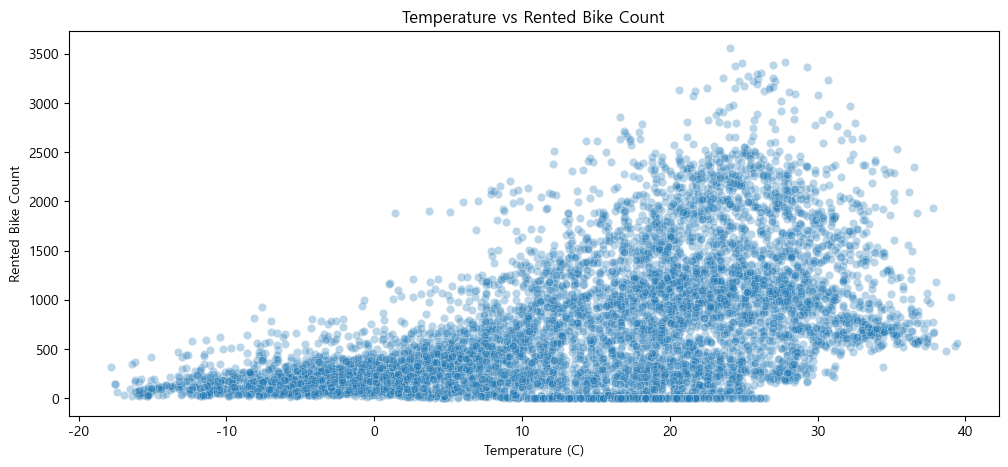

In [411]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=data_train1, x='Temperature(째C)', y='Rented Bike Count', alpha=0.3)
plt.title('Temperature vs Rented Bike Count') # 그래프 제목
plt.xlabel('Temperature (C)')
plt.ylabel('Rented Bike Count')

Text(0, 0.5, 'Rented Bike Count')

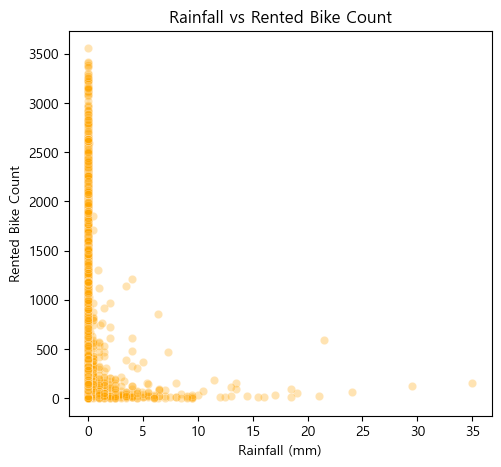

In [412]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 영역
sns.scatterplot(data=data_train1, x='Rainfall(mm)', y='Rented Bike Count', alpha=0.3, color='orange')
plt.title('Rainfall vs Rented Bike Count')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Rented Bike Count')

In [413]:
data_train1.groupby('Hour')['Rented Bike Count'].mean()

Hour
0      547.307463
1      429.650746
2      304.826866
3      205.262687
4      133.791045
5      141.110448
6      290.238806
7      604.826866
8     1002.683582
9      641.728358
10     526.376119
11     600.346269
12     699.752239
13     734.232836
14     760.704478
15     832.638806
16     936.698507
17    1146.785075
18    1514.573134
19    1213.970149
20    1091.002985
21    1053.498507
22     939.161194
23     683.456716
Name: Rented Bike Count, dtype: float64

In [414]:
data_train1.pivot_table(index='Hour', columns='Seasons', values='Rented Bike Count', aggfunc='mean')

Seasons,Autumn,Spring,Summer,Winter
Hour,,,,
0,696.229508,470.630435,899.065217,165.177778
1,534.032787,356.032609,698.771739,159.055556
2,364.262295,247.467391,505.750000,117.788889
3,247.065574,164.815217,342.673913,77.811111
4,163.049180,105.869565,223.815217,50.477778
5,157.049180,113.652174,245.934783,51.222222
6,344.721311,251.641304,485.836957,92.822222
7,743.016393,601.913043,902.782609,209.566667
8,1215.016393,1013.847826,1418.597826,422.200000


In [415]:
data_train1.pivot_table(index='Hour', columns='Holiday', values='Rented Bike Count', aggfunc='mean')

Holiday,Holiday,No Holiday
Hour,,
0,466.166667,551.914826
1,393.333333,431.712934
2,303.888889,304.880126
3,212.333333,204.861199
4,128.388889,134.097792
5,89.000000,144.069401
6,132.833333,299.176656
7,214.277778,627.003155
8,348.500000,1039.829653


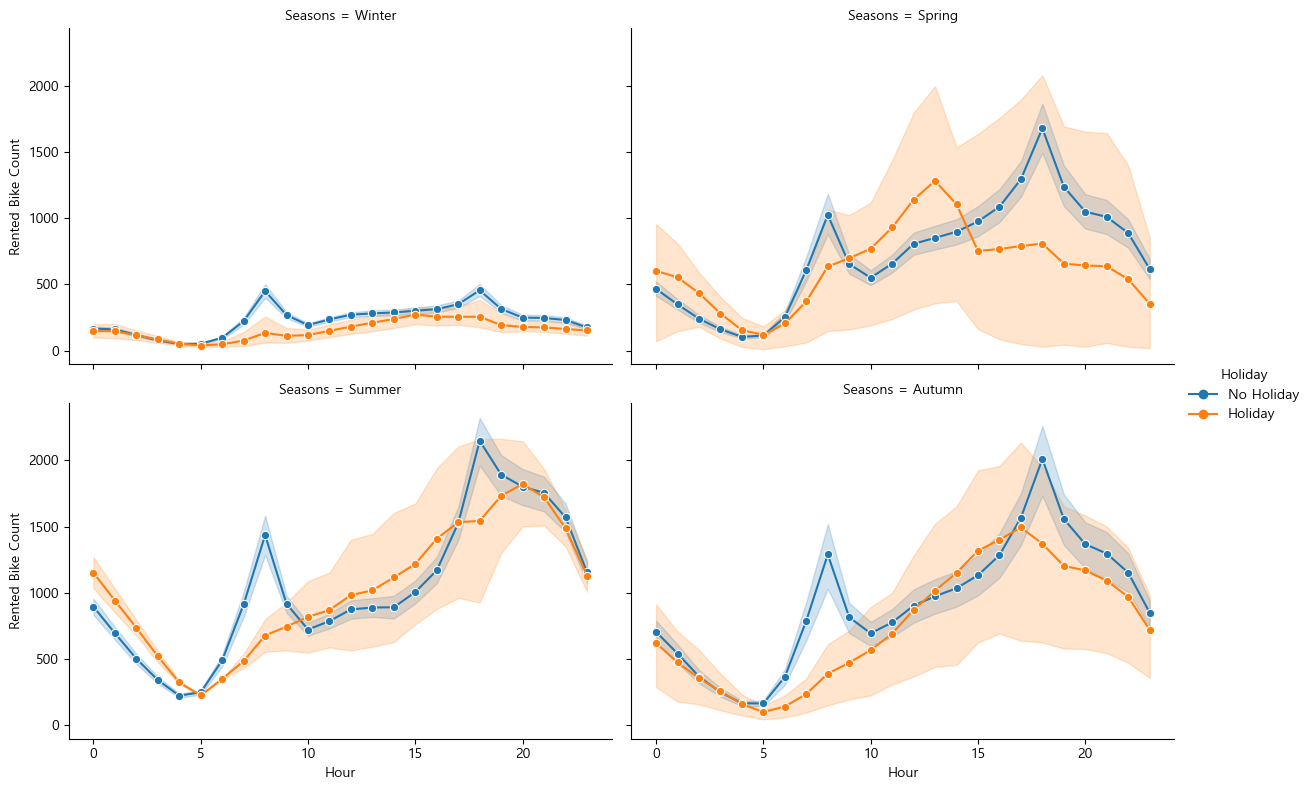

In [416]:
sns.relplot(
    data=data_train1, 
    x='Hour', 
    y='Rented Bike Count', 
    hue='Holiday',      # 선 색상을 휴일 여부('Holiday' / 'No Holiday')로 구분
    col='Seasons',      # 그래프 자체를 'Seasons' 기준으로 4개로 분리
    col_wrap=2,         # 한 줄에 그래프를 2개씩만 배치 (위아래 2x2 배열로 보기 좋게 설정)
    kind='line',        # 선 그래프로 지정
    marker='o',         # 시간대별로 점 찍기
    height=4,           # 각 그래프의 세로 크기
    aspect=1.5          # 각 그래프의 가로세로 비율
)

plt.show()

#계절별 휴일과 휴일 아닌 날의 시간(Hour)별 대여량
#출퇴근 시간에 격차가 가장 크고 그 외에는 크게 차이 X, 전체적으로 휴일 아닌 날이 대여량 더 높음

# 시간대별 자전거 대여량 차이가 있는지 검정

* F검정

In [417]:
import scipy.stats as stats

In [418]:
hourly_groups = [data_train1[data_train1['Hour'] == h]['Rented Bike Count'] for h in range(24)].copy()

In [419]:
f_stat, p_value = stats.f_oneway(*hourly_groups)

In [420]:
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

F-statistic: 140.6466
p-value: 0.0000e+00


In [421]:
if p_value < 0.05:
    print("결과: 귀무가설 기각 (시간대별로 자전거 대여량 평균에 유의미한 차이가 존재함)")
else:
    print("결과: 귀무가설 채택 (시간대별로 자전거 대여량 평균에 차이가 없음)")

결과: 귀무가설 기각 (시간대별로 자전거 대여량 평균에 유의미한 차이가 존재함)


* T검정

In [422]:
holiday_demand = data_train1[data_train1['Holiday'] == 'Holiday']['Rented Bike Count']
no_holiday_demand = data_train1[data_train1['Holiday'] == 'No Holiday']['Rented Bike Count']

In [423]:
t_stat, p_value = stats.ttest_ind(holiday_demand, no_holiday_demand, equal_var=False)

In [424]:
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

t-statistic: -7.7918
p-value: 3.8683e-14


In [425]:
if p_value < 0.05:
    print("결과: 귀무가설 기각 (휴일과 평일의 자전거 대여량 평균은 유의미한 차이가 존재함)")
else:
    print("결과: 귀무가설 채택 (휴일과 평일의 자전거 대여량 평균은 유의미한 차이가 존재하지 않음)")

결과: 귀무가설 기각 (휴일과 평일의 자전거 대여량 평균은 유의미한 차이가 존재함)


# 강수 여부에 따른 자전거 대여량 검정

In [426]:
clear_days = data_train1[data_train1['Rainfall(mm)'] == 0]['Rented Bike Count']
rainy_days = data_train1[data_train1['Rainfall(mm)'] > 0]['Rented Bike Count']

In [427]:
t_stat, p_value = stats.ttest_ind(clear_days, rainy_days, equal_var=False)

In [428]:
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

t-statistic: 41.6740
p-value: 2.0386e-222


In [429]:
if p_value < 0.05:
    print("결과: 귀무가설 기각 (비가 온 날과 안 온 날의 자전거 대여량 평균은 유의미한 차이가 존재함)")
else:
    print("결과: 귀무가설 채택 (비가 온 날과 안 온 날의 자전거 대여량 평균은 유의미한 차이가 존재하지 않음)")

결과: 귀무가설 기각 (비가 온 날과 안 온 날의 자전거 대여량 평균은 유의미한 차이가 존재함)


In [430]:
data_train1['Functioning Day'].value_counts()

Functioning Day
Yes    7817
No      223
Name: count, dtype: int64

In [431]:
data_train1['Holiday'].value_counts()

Holiday
No Holiday    7608
Holiday        432
Name: count, dtype: int64

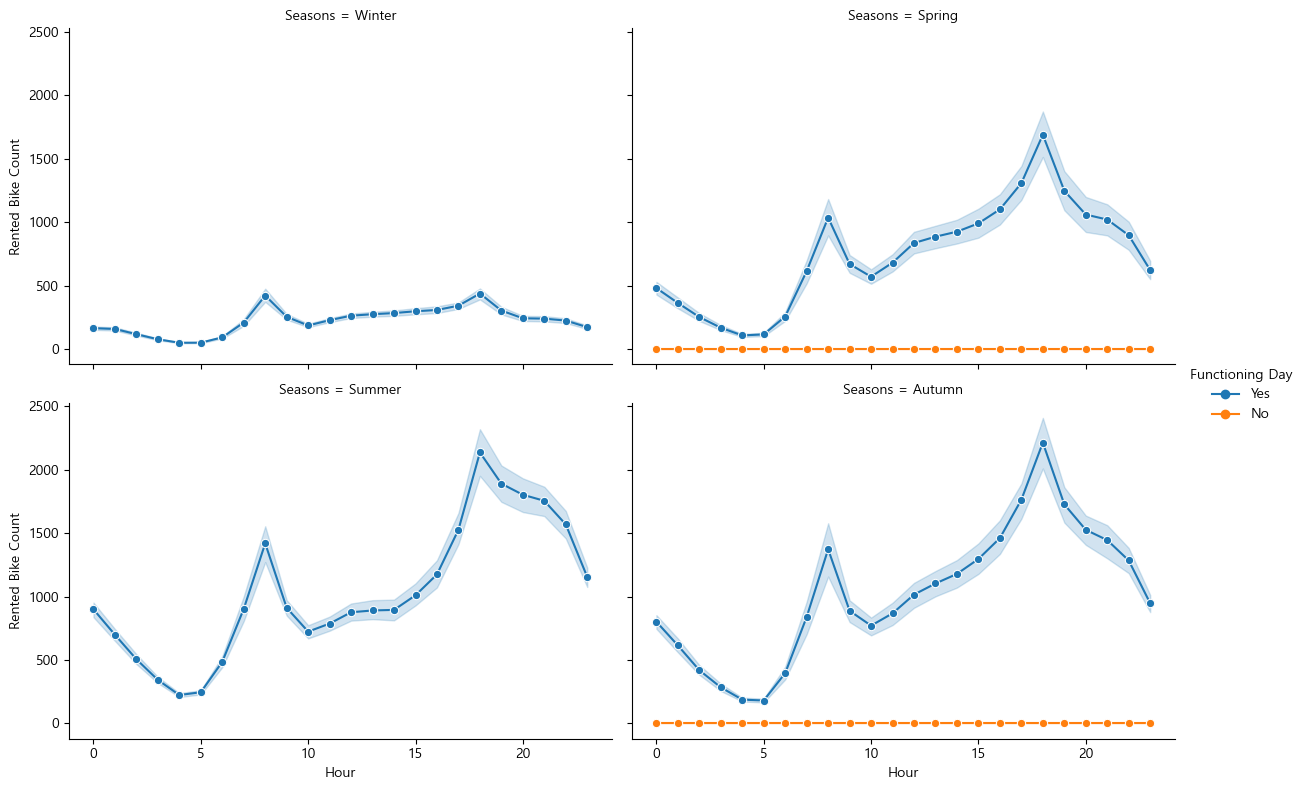

In [432]:
sns.relplot(
    data=data_train1, 
    x='Hour', 
    y='Rented Bike Count', 
    hue='Functioning Day',      # 선 색상을 Functioning Day로 구분
    col='Seasons',      # 그래프 자체를 'Seasons' 기준으로 4개로 분리
    col_wrap=2,         # 한 줄에 그래프를 2개씩만 배치 (위아래 2x2 배열로 보기 좋게 설정)
    kind='line',        # 선 그래프로 지정
    marker='o',         # 시간대별로 점 찍기
    height=4,           # 각 그래프의 세로 크기
    aspect=1.5          # 각 그래프의 가로세로 비율
)

plt.show()

In [433]:
data_train1[data_train1['Functioning Day'] == 'No']

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
3144,2018-04-11,0,0,14.4,82,4.6,1041,11.3,0.0,0.0,0.0,Spring,No Holiday,No
3145,2018-04-11,0,1,13.6,81,3.6,886,10.3,0.0,0.0,0.0,Spring,No Holiday,No
3146,2018-04-11,0,2,12.7,80,3.9,885,9.3,0.0,0.0,0.0,Spring,No Holiday,No
3147,2018-04-11,0,3,11.6,81,3.1,687,8.4,0.0,0.0,0.0,Spring,No Holiday,No
3148,2018-04-11,0,4,10.2,83,3.5,554,7.4,0.0,0.0,0.0,Spring,No Holiday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7507,2018-10-09,0,19,17.3,47,2.2,2000,5.8,0.0,0.0,0.0,Autumn,Holiday,No
7508,2018-10-09,0,20,17.0,49,1.4,2000,6.1,0.0,0.0,0.0,Autumn,Holiday,No
7509,2018-10-09,0,21,16.8,52,1.6,2000,6.8,0.0,0.0,0.0,Autumn,Holiday,No
7510,2018-10-09,0,22,16.7,55,1.9,2000,7.6,0.0,0.0,0.0,Autumn,Holiday,No


In [434]:
data_train1[data_train1['Functioning Day'] == 'No']['Rented Bike Count'].describe()

count    223.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Rented Bike Count, dtype: float64

* 'Functioning Day'가 No인 날들의 경우 대여량이 모두 0이다.
* 결측치 처리하기 or 행 삭제?

* data_train2는 Functioning Day가 No인 행들을 다 지운 것

In [435]:
# data_train2는 Functioning Day가 No일 때 Rented Bike Count를 결측치 처리한 것
# data_train2 = data_train1.copy()
# data_train2.loc[data_train2['Functioning Day'] == 'No', 'Rented Bike Count'] = np.nan

In [608]:
data_train2 = data_train1[data_train1['Functioning Day'] == 'Yes'].copy()

In [609]:
data_train2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7817 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       7817 non-null   datetime64[ns]
 1   Rented Bike Count          7817 non-null   int64         
 2   Hour                       7817 non-null   int64         
 3   Temperature(째C)            7817 non-null   float64       
 4   Humidity(%)                7817 non-null   int64         
 5   Wind speed (m/s)           7817 non-null   float64       
 6   Visibility (10m)           7817 non-null   int64         
 7   Dew point temperature(째C)  7817 non-null   float64       
 8   Solar Radiation (MJ/m2)    7817 non-null   float64       
 9   Rainfall(mm)               7817 non-null   float64       
 10  Snowfall (cm)              7817 non-null   float64       
 11  Seasons                    7817 non-null   object        
 12  Holiday    

In [610]:
print(data_train1['Rented Bike Count'].mean())
print(data_train2['Rented Bike Count'].mean())

709.7759950248757
730.0241780734297


In [611]:
data_train2.groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    1027.375485
Spring     746.254167
Summer    1034.073370
Winter     225.541204
Name: Rented Bike Count, dtype: float64

In [612]:
data_train2[data_train2['Rainfall(mm)'] > 0.1].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    169.242857
Spring     88.327684
Summer    222.750000
Winter     75.457143
Name: Rented Bike Count, dtype: float64

In [616]:
data_train2[data_train2['Rainfall(mm)'] > 0.0].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    172.328767
Spring     91.811518
Summer    257.893401
Winter     87.414634
Name: Rented Bike Count, dtype: float64

In [619]:
data_train2[data_train2['Snowfall (cm)'] > 3.6].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Winter    85.666667
Name: Rented Bike Count, dtype: float64

In [620]:
data_train2[data_train2['Snowfall (cm)'] > 3.7].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Winter    56.111111
Name: Rented Bike Count, dtype: float64

In [617]:
data_train2[(data_train2['Rainfall(mm)'] > 0.1) | (data_train2['Snowfall (cm)'] > 3.6)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    169.242857
Spring     88.327684
Summer    222.750000
Winter     81.980769
Name: Rented Bike Count, dtype: float64

In [613]:
data_train2[(data_train2['Rainfall(mm)'] > 0.1) | (data_train2['Snowfall (cm)'] > 3.7)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    169.242857
Spring     88.327684
Summer    222.750000
Winter     70.897959
Name: Rented Bike Count, dtype: float64

In [614]:
data_train2[(data_train2['Rainfall(mm)'] > 0.0) | (data_train2['Snowfall (cm)'] > 0.0)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    172.328767
Spring     91.811518
Summer    257.893401
Winter    154.226044
Name: Rented Bike Count, dtype: float64

In [615]:
data_train2[(data_train2['Rainfall(mm)'] == 0.0) & (data_train2['Snowfall (cm)'] == 0.0)].groupby('Seasons')['Rented Bike Count'].mean()

Seasons
Autumn    1078.706414
Spring     809.737430
Summer    1110.108901
Winter     242.098688
Name: Rented Bike Count, dtype: float64

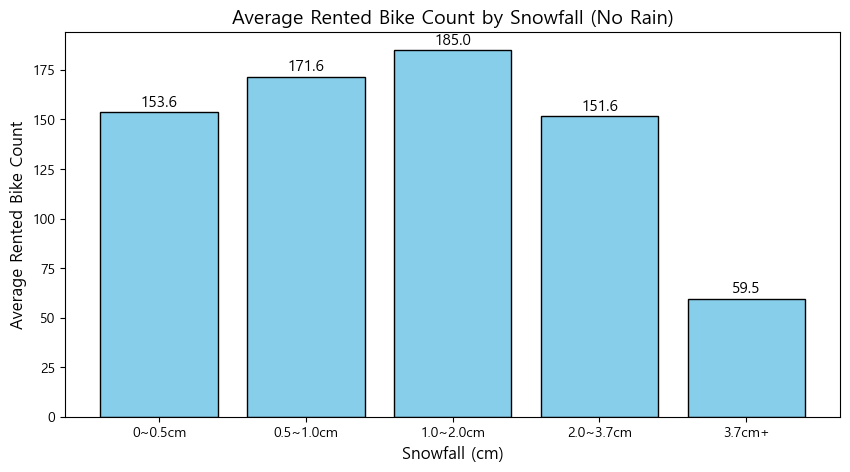

In [621]:
snow_only = data_train2[(data_train2['Rainfall(mm)'] == 0.0) & (data_train2['Snowfall (cm)'] > 0.0)].copy()
bins = [0, 0.5, 1.0, 2.0, 3.7, np.inf]
labels = ['0~0.5cm', '0.5~1.0cm', '1.0~2.0cm', '2.0~3.7cm', '3.7cm+']
snow_only['Snow_Bin'] = pd.cut(snow_only['Snowfall (cm)'], bins=bins, labels=labels)
snow_mean = snow_only.groupby('Snow_Bin', observed=True)['Rented Bike Count'].mean()
plt.figure(figsize=(10, 5))
plt.bar(snow_mean.index.astype(str), snow_mean.values, color='skyblue', edgecolor='black')
plt.title('Average Rented Bike Count by Snowfall (No Rain)', fontsize=14)
plt.xlabel('Snowfall (cm)', fontsize=12)
plt.ylabel('Average Rented Bike Count', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(snow_mean.values):
    plt.text(i, v + 3, str(round(v, 1)), ha='center', fontsize=11)

plt.show()

In [622]:
#비는 조금 와도 대여량이 확 줄지만 눈은 3.7 이상 올 때 대여량이 크게 감소한다는 점을 이용하여
#Bad_Weather는 강수량>0 | 적설량 > 3.7일때로 설정

In [623]:
data_train2['Bad_Weather'] = ((data_train2['Rainfall(mm)'] > 0) | (data_train2['Snowfall (cm)'] > 3.7)).astype(int)

In [627]:
data_train2['Bad_Weather'].value_counts()

Bad_Weather
0    7301
1     516
Name: count, dtype: int64

In [628]:
data_train2.loc[data_train2['Temperature(째C)'] < -5, 'Rented Bike Count']

0       254
1       204
2       173
3       107
4        78
       ... 
2188     47
2189     65
2190    135
2191    401
2192    617
Name: Rented Bike Count, Length: 698, dtype: int64

In [629]:
data_train2[['Temperature(째C)', 'Rainfall(mm)', 'Rented Bike Count']].corr()

,Temperature(째C),Rainfall(mm),Rented Bike Count
Temperature(째C),1.000000,0.050919,0.573206
Rainfall(mm),0.050919,1.000000,-0.128288
Rented Bike Count,0.573206,-0.128288,1.000000


Text(0, 0.5, 'Rented Bike Count')

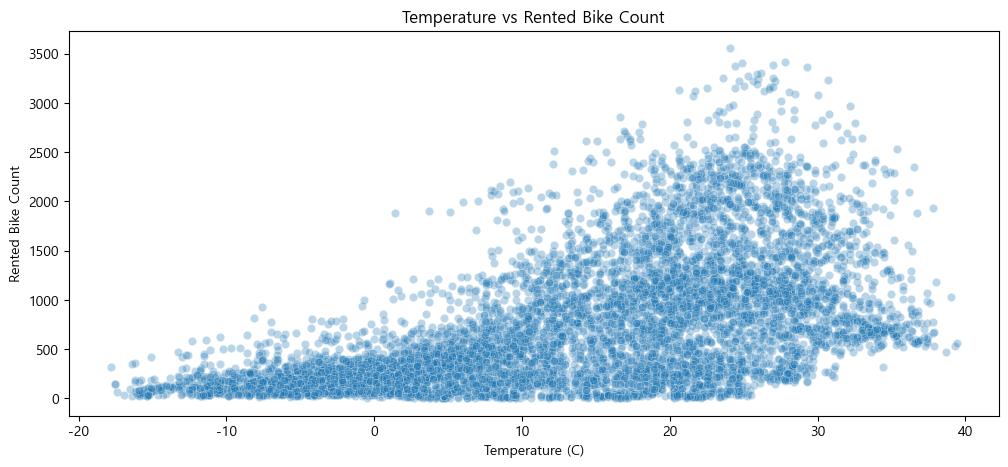

In [630]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=data_train2, x='Temperature(째C)', y='Rented Bike Count', alpha=0.3)
plt.title('Temperature vs Rented Bike Count') # 그래프 제목
plt.xlabel('Temperature (C)')
plt.ylabel('Rented Bike Count')

Text(0, 0.5, 'Rented Bike Count')

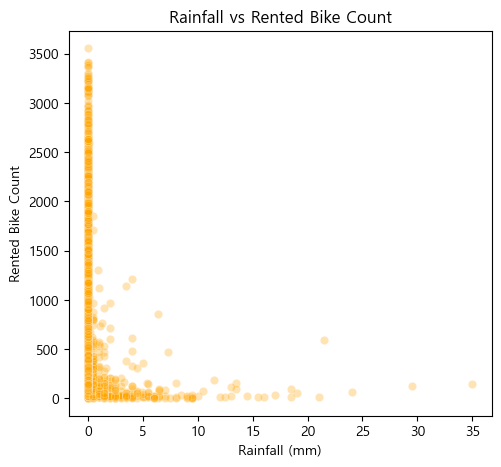

In [631]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 영역
sns.scatterplot(data=data_train2, x='Rainfall(mm)', y='Rented Bike Count', alpha=0.3, color='orange')
plt.title('Rainfall vs Rented Bike Count')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Rented Bike Count')

In [632]:
data_train2.groupby('Hour')['Rented Bike Count'].mean()

Hour
0      564.147692
1      442.870769
2      314.206154
3      211.578462
4      137.907692
5      145.452308
6      299.169231
7      621.524540
8     1030.365031
9      659.444785
10     540.907975
11     616.920245
12     719.070552
13     754.503067
14     781.705521
15     855.625767
16     962.558282
17    1178.444785
18    1556.386503
19    1247.484663
20    1121.122699
21    1082.582822
22     965.088957
23     702.325153
Name: Rented Bike Count, dtype: float64

In [633]:
data_train2.pivot_table(index='Hour', columns='Seasons', values='Rented Bike Count', aggfunc='mean')

Seasons,Autumn,Spring,Summer,Winter
Hour,,,,
0,801.320755,481.088889,899.065217,165.177778
1,614.641509,363.944444,698.771739,159.055556
2,419.245283,252.966667,505.750000,117.788889
3,284.358491,168.477778,342.673913,77.811111
4,187.660377,108.222222,223.815217,50.477778
5,180.754717,116.177778,245.934783,51.222222
6,396.754717,257.233333,485.836957,92.822222
7,839.333333,615.288889,902.782609,209.566667
8,1372.518519,1036.377778,1418.597826,422.200000


In [634]:
data_train2.pivot_table(index='Hour', columns='Holiday', values='Rented Bike Count', aggfunc='mean')

Holiday,Holiday,No Holiday
Hour,,
0,493.588235,568.042208
1,416.470588,444.327922
2,321.764706,313.788961
3,224.823529,210.847403
4,135.941176,138.016234
5,94.235294,148.279221
6,140.647059,307.918831
7,226.882353,643.236246
8,369.000000,1066.750809


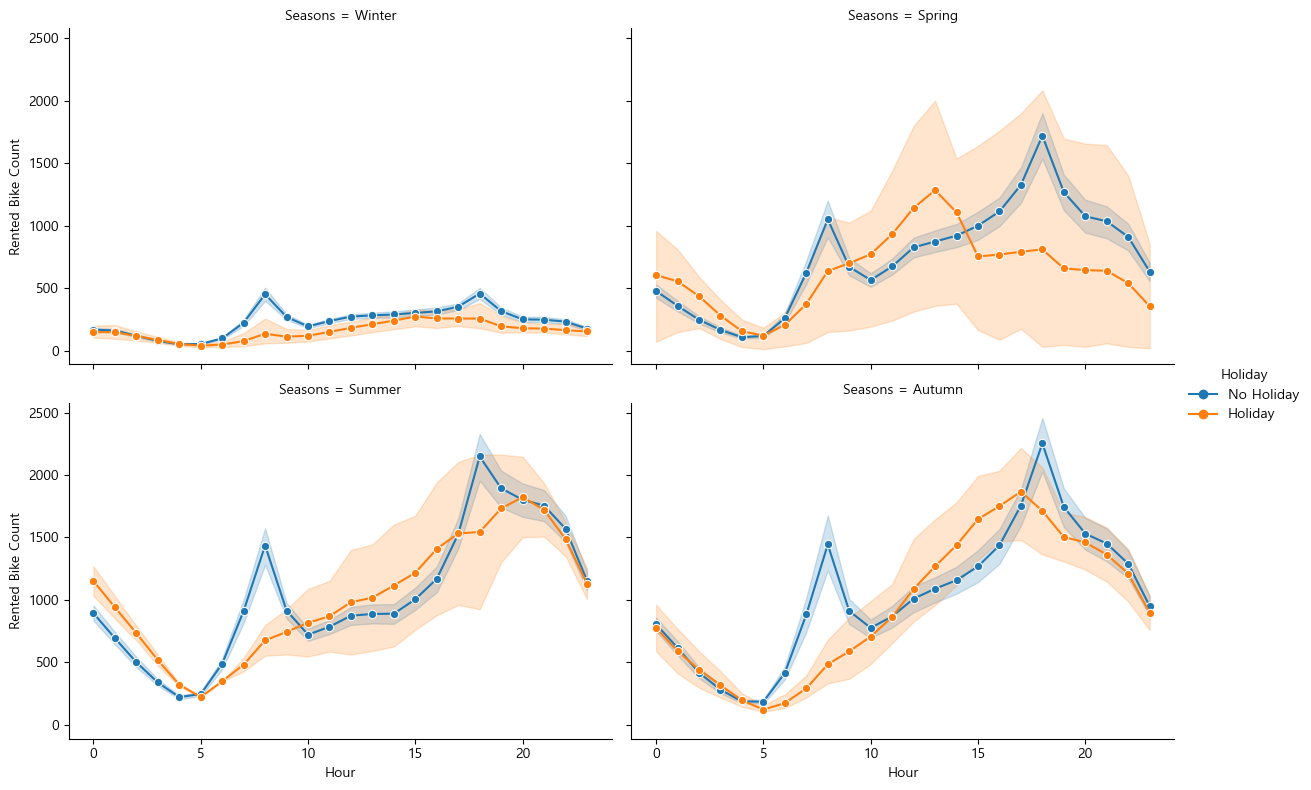

In [635]:
sns.relplot(
    data=data_train2, 
    x='Hour', 
    y='Rented Bike Count', 
    hue='Holiday',      # 선 색상을 휴일 여부('Holiday' / 'No Holiday')로 구분
    col='Seasons',      # 그래프 자체를 'Seasons' 기준으로 4개로 분리
    col_wrap=2,         # 한 줄에 그래프를 2개씩만 배치 (위아래 2x2 배열로 보기 좋게 설정)
    kind='line',        # 선 그래프로 지정
    marker='o',         # 시간대별로 점 찍기
    height=4,           # 각 그래프의 세로 크기
    aspect=1.5          # 각 그래프의 가로세로 비율
)

plt.show()

In [636]:
hourly_groups = [data_train2[data_train2['Hour'] == h]['Rented Bike Count'] for h in range(24)].copy()

In [637]:
f_stat, p_value = stats.f_oneway(*hourly_groups)

In [638]:
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

F-statistic: 148.5186
p-value: 0.0000e+00


In [639]:
if p_value < 0.05:
    print("결과: 귀무가설 기각 (시간대별로 자전거 대여량 평균에 유의미한 차이가 존재함)")
else:
    print("결과: 귀무가설 채택 (시간대별로 자전거 대여량 평균에 차이가 없음)")

결과: 귀무가설 기각 (시간대별로 자전거 대여량 평균에 유의미한 차이가 존재함)


In [640]:
data_train2[['Wind speed (m/s)', 'Rented Bike Count']].corr()

,Wind speed (m/s),Rented Bike Count
Wind speed (m/s),1.000000,0.122185
Rented Bike Count,0.122185,1.000000


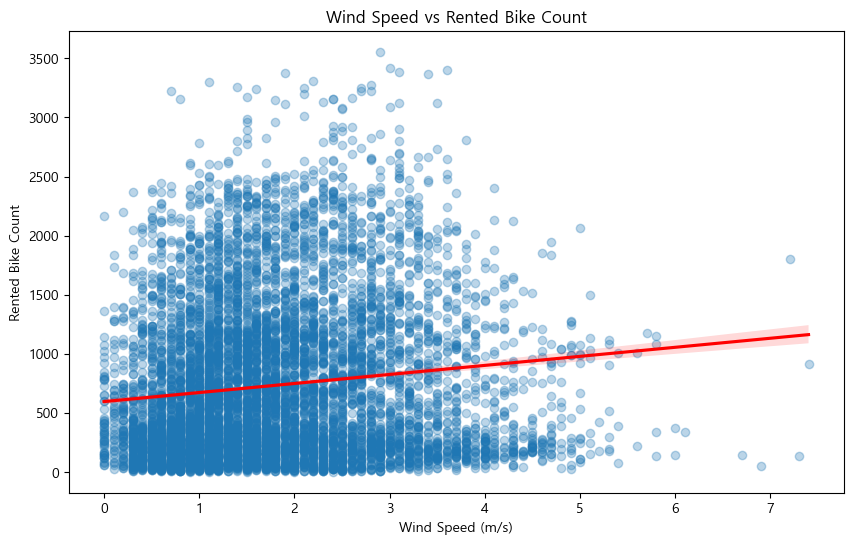

In [641]:
plt.figure(figsize=(10, 6))

# regplot: 산점도와 함께 선형 추세선을 그려줌
# scatter_kws={'alpha': 0.3} : 점들의 투명도를 주어 밀집도를 파악
# line_kws={'color': 'red'} : 눈에 띄도록 추세선을 빨간색으로 지정
sns.regplot(
    data=data_train2, 
    x='Wind speed (m/s)', 
    y='Rented Bike Count', 
    scatter_kws={'alpha': 0.3}, 
    line_kws={'color': 'red'}
)

plt.title('Wind Speed vs Rented Bike Count')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Rented Bike Count')

plt.show()

In [642]:
data_train2['Temperature(째C)'].describe()

count    7817.000000
mean       13.219227
std        12.425536
min       -17.800000
25%         2.900000
50%        15.100000
75%        23.300000
max        39.400000
Name: Temperature(째C), dtype: float64

In [643]:
data_train2['Humidity(%)'].describe()

count    7817.000000
mean       58.255213
std        20.445092
min         0.000000
25%        42.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: Humidity(%), dtype: float64

In [644]:
print((data_train2['Humidity(%)'] == 0).sum())
data_train2[data_train2['Humidity(%)'] == 0 ]

17


,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
4063,2018-05-19,436,7,11.4,0,1.4,2000,4.5,0.46,0.0,0.0,Spring,No Holiday,Yes,0
4106,2018-05-21,262,2,13.9,0,0.9,2000,-2.1,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4107,2018-05-21,165,3,13.0,0,0.8,2000,-2.5,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4108,2018-05-21,113,4,12.4,0,0.8,2000,-3.4,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4109,2018-05-21,200,5,11.9,0,1.3,2000,-2.7,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4110,2018-05-21,467,6,11.4,0,0.9,2000,-2.0,0.03,0.0,0.0,Spring,No Holiday,Yes,0
4111,2018-05-21,1135,7,12.3,0,0.9,1989,-2.7,0.48,0.0,0.0,Spring,No Holiday,Yes,0
4131,2018-05-22,406,3,15.5,0,0.7,1420,10.4,0.00,0.0,0.0,Spring,Holiday,Yes,0
4132,2018-05-22,248,4,15.6,0,0.5,1502,10.5,0.00,0.0,0.0,Spring,Holiday,Yes,0
4133,2018-05-22,182,5,15.7,0,0.6,1610,10.6,0.00,0.0,0.0,Spring,Holiday,Yes,0


In [645]:
data_train2[4055:4059]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
4103,2018-05-20,943,23,15.8,30,1.1,2000,-1.7,0.0,0.0,0.0,Spring,No Holiday,Yes,0
4104,2018-05-21,666,0,15.3,29,1.3,2000,-2.6,0.0,0.0,0.0,Spring,No Holiday,Yes,0
4105,2018-05-21,420,1,14.5,31,1.1,2000,-2.4,0.0,0.0,0.0,Spring,No Holiday,Yes,0
4106,2018-05-21,262,2,13.9,0,0.9,2000,-2.1,0.0,0.0,0.0,Spring,No Holiday,Yes,0


In [646]:
data_train2 = data_train2.reset_index(drop=True)

In [647]:
print((data_train2['Humidity(%)'] == 0).sum())
data_train2[data_train2['Humidity(%)'] == 0 ]

17


,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
4015,2018-05-19,436,7,11.4,0,1.4,2000,4.5,0.46,0.0,0.0,Spring,No Holiday,Yes,0
4058,2018-05-21,262,2,13.9,0,0.9,2000,-2.1,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4059,2018-05-21,165,3,13.0,0,0.8,2000,-2.5,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4060,2018-05-21,113,4,12.4,0,0.8,2000,-3.4,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4061,2018-05-21,200,5,11.9,0,1.3,2000,-2.7,0.00,0.0,0.0,Spring,No Holiday,Yes,0
4062,2018-05-21,467,6,11.4,0,0.9,2000,-2.0,0.03,0.0,0.0,Spring,No Holiday,Yes,0
4063,2018-05-21,1135,7,12.3,0,0.9,1989,-2.7,0.48,0.0,0.0,Spring,No Holiday,Yes,0
4083,2018-05-22,406,3,15.5,0,0.7,1420,10.4,0.00,0.0,0.0,Spring,Holiday,Yes,0
4084,2018-05-22,248,4,15.6,0,0.5,1502,10.5,0.00,0.0,0.0,Spring,Holiday,Yes,0
4085,2018-05-22,182,5,15.7,0,0.6,1610,10.6,0.00,0.0,0.0,Spring,Holiday,Yes,0


In [648]:
data_train2.loc[4015, 'Humidity(%)'] = 63
data_train2.loc[4058, 'Humidity(%)'] = 33
data_train2.loc[4059, 'Humidity(%)'] = 34
data_train2.loc[4060, 'Humidity(%)'] = 33
data_train2.loc[4061, 'Humidity(%)'] = 36
data_train2.loc[4062, 'Humidity(%)'] = 39
data_train2.loc[4063, 'Humidity(%)'] = 35
data_train2.loc[4083, 'Humidity(%)'] = 72
data_train2.loc[4084, 'Humidity(%)'] = 72
data_train2.loc[4085, 'Humidity(%)'] = 72
data_train2.loc[4086, 'Humidity(%)'] = 72
data_train2.loc[4205, 'Humidity(%)'] = 60
data_train2.loc[4207, 'Humidity(%)'] = 56
data_train2.loc[4228, 'Humidity(%)'] = 58
data_train2.loc[4229, 'Humidity(%)'] = 64
data_train2.loc[4230, 'Humidity(%)'] = 64
data_train2.loc[4231, 'Humidity(%)'] = 60

In [649]:
print((data_train2['Humidity(%)'] == 0).sum())

0


In [650]:
data_train2.describe()

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Bad_Weather
count,7817,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000
mean,2018-05-14 02:42:17.546373120,730.024178,11.507612,13.219227,58.373289,1.757618,1451.378406,4.404158,0.584987,0.153793,0.068389,0.066010
min,2017-12-01 00:00:00,2.000000,0.000000,-17.800000,10.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,2018-02-20 00:00:00,210.000000,6.000000,2.900000,43.000000,1.000000,965.000000,-5.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-05-14 00:00:00,516.000000,12.000000,15.100000,57.000000,1.600000,1728.000000,6.000000,0.020000,0.000000,0.000000,0.000000
75%,2018-08-04 00:00:00,1100.000000,18.000000,23.300000,74.000000,2.400000,2000.000000,15.800000,0.950000,0.000000,0.000000,0.000000
max,2018-10-31 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,5.100000,1.000000
std,NaN,655.449707,6.920792,12.425536,20.276450,1.045796,606.182069,13.544424,0.884698,1.137057,0.383370,0.248315


In [651]:
print((data_train2['Wind speed (m/s)'] == 0).sum())

54


In [652]:
data_train2[data_train2['Wind speed (m/s)'] == 0 ]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
107,2017-12-05,334,11,-3.9,25,0.0,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
108,2017-12-05,321,12,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes,0
109,2017-12-05,325,13,-1.6,27,0.0,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0
110,2017-12-05,334,14,-1.1,28,0.0,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes,0
111,2017-12-05,353,15,-0.7,28,0.0,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes,0
112,2017-12-05,435,16,-0.5,30,0.0,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
113,2017-12-05,529,17,-1.6,35,0.0,2000,-15.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0
114,2017-12-05,789,18,-2.6,40,0.0,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
115,2017-12-05,597,19,-3.2,45,0.0,2000,-13.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0
116,2017-12-05,418,20,-3.5,46,0.0,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0


In [653]:
# 일부 데이터는 결측치가 0으로 들어간 경우도 있고 실제로 0으로 측정된 경우도 있음

In [654]:
# 기상청 데이터 검색할 때 QC 플래그(여기서는 풍속 QC 플래그)까지 같이 보면 
# 풍속 QC 플래그가 0으로 나오면 정상, 1로 나오면 오류, 9로 나오면 결측치인데 풍속이 0임에도 풍속 QC플래그가 0인 경우도 있어 일일이 대조 필요해보임

In [655]:
data_train2.loc[data_train2['Wind speed (m/s)'] == 0, 'Wind speed (m/s)'] = np.nan
#일단 풍속 0인걸 결측치 처리하고 진짜 0인 값은 0 대입

In [656]:
data_train2[data_train2['Wind speed (m/s)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
107,2017-12-05,334,11,-3.9,25,NaN,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
108,2017-12-05,321,12,-2.3,25,NaN,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes,0
109,2017-12-05,325,13,-1.6,27,NaN,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0
110,2017-12-05,334,14,-1.1,28,NaN,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes,0
111,2017-12-05,353,15,-0.7,28,NaN,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes,0
112,2017-12-05,435,16,-0.5,30,NaN,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
113,2017-12-05,529,17,-1.6,35,NaN,2000,-15.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0
114,2017-12-05,789,18,-2.6,40,NaN,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
115,2017-12-05,597,19,-3.2,45,NaN,2000,-13.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0
116,2017-12-05,418,20,-3.5,46,NaN,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0


In [657]:
data_train2[118:130]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
118,2017-12-05,393,22,-2.8,49,0.8,2000,-12.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
119,2017-12-05,244,23,-2.5,59,NaN,1210,-9.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
120,2017-12-06,145,0,-2.8,77,NaN,331,-6.2,0.00,0.1,0.1,Winter,No Holiday,Yes,1
121,2017-12-06,144,1,-3.0,79,NaN,293,-6.1,0.00,0.0,0.3,Winter,No Holiday,Yes,0
122,2017-12-06,117,2,-3.0,79,NaN,1862,-6.1,0.00,0.0,0.4,Winter,No Holiday,Yes,0
123,2017-12-06,78,3,-3.2,78,NaN,1808,-6.4,0.00,0.2,0.4,Winter,No Holiday,Yes,1
124,2017-12-06,58,4,-3.4,75,NaN,1982,-7.2,0.00,0.0,0.4,Winter,No Holiday,Yes,0
125,2017-12-06,87,5,-3.6,76,NaN,1934,-7.2,0.00,0.0,0.4,Winter,No Holiday,Yes,0
126,2017-12-06,142,6,-3.7,76,NaN,1864,-7.3,0.00,0.0,0.4,Winter,No Holiday,Yes,0
127,2017-12-06,379,7,-4.2,77,NaN,1741,-7.6,0.00,0.0,0.3,Winter,No Holiday,Yes,0


In [658]:
data_train2.loc[118, 'Wind speed (m/s)'] = np.nan

In [659]:
data_train2.loc[129, 'Wind speed (m/s)'] = np.nan

In [660]:
data_train2[data_train2['Wind speed (m/s)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
107,2017-12-05,334,11,-3.9,25,NaN,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
108,2017-12-05,321,12,-2.3,25,NaN,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes,0
109,2017-12-05,325,13,-1.6,27,NaN,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0
110,2017-12-05,334,14,-1.1,28,NaN,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes,0
111,2017-12-05,353,15,-0.7,28,NaN,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes,0
112,2017-12-05,435,16,-0.5,30,NaN,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
113,2017-12-05,529,17,-1.6,35,NaN,2000,-15.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0
114,2017-12-05,789,18,-2.6,40,NaN,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
115,2017-12-05,597,19,-3.2,45,NaN,2000,-13.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0
116,2017-12-05,418,20,-3.5,46,NaN,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0


In [661]:
data_train2.loc[1899, 'Wind speed (m/s)'] = 0

In [662]:
data_train2[data_train2['Wind speed (m/s)'] == 0 ]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
1899,2018-02-18,56,3,-4.5,26,0.0,2000,-21.1,0.0,0.0,0.0,Winter,No Holiday,Yes,0


In [663]:
data_train2.loc[1994, 'Wind speed (m/s)'] = 0

In [664]:
data_train2.loc[4629, 'Wind speed (m/s)'] = 0

In [665]:
data_train2.loc[4996, 'Wind speed (m/s)'] = 0

In [666]:
data_train2.loc[5089, 'Wind speed (m/s)'] = 0
data_train2.loc[5091, 'Wind speed (m/s)'] = 0
data_train2.loc[5093, 'Wind speed (m/s)'] = 0

In [667]:
data_train2.loc[5305, 'Wind speed (m/s)'] = 0

In [668]:
data_train2.loc[5500, 'Wind speed (m/s)'] = 0

In [669]:
data_train2.loc[5526, 'Wind speed (m/s)'] = 0

In [670]:
data_train2.loc[5707, 'Wind speed (m/s)'] = 0

In [671]:
data_train2.loc[5810, 'Wind speed (m/s)'] = 0

In [672]:
data_train2.loc[5957, 'Wind speed (m/s)'] = 0

In [673]:
data_train2.loc[5999, 'Wind speed (m/s)'] = 0

In [674]:
data_train2.loc[[6510, 6606, 6724, 6986, 6992, 7385, 7412, 7461, 7462, 7510, 7530, 7551, 7552, 7553, 7575, 7576, 7599, 7795], 'Wind speed (m/s)'] = 0

In [675]:
data_train2[data_train2['Wind speed (m/s)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
107,2017-12-05,334,11,-3.9,25,NaN,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
108,2017-12-05,321,12,-2.3,25,NaN,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes,0
109,2017-12-05,325,13,-1.6,27,NaN,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0
110,2017-12-05,334,14,-1.1,28,NaN,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes,0
111,2017-12-05,353,15,-0.7,28,NaN,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes,0
112,2017-12-05,435,16,-0.5,30,NaN,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
113,2017-12-05,529,17,-1.6,35,NaN,2000,-15.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0
114,2017-12-05,789,18,-2.6,40,NaN,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
115,2017-12-05,597,19,-3.2,45,NaN,2000,-13.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0
116,2017-12-05,418,20,-3.5,46,NaN,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0


In [676]:
data_train2.loc[107:130]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather
107,2017-12-05,334,11,-3.9,25,NaN,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
108,2017-12-05,321,12,-2.3,25,NaN,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes,0
109,2017-12-05,325,13,-1.6,27,NaN,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes,0
110,2017-12-05,334,14,-1.1,28,NaN,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes,0
111,2017-12-05,353,15,-0.7,28,NaN,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes,0
112,2017-12-05,435,16,-0.5,30,NaN,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes,0
113,2017-12-05,529,17,-1.6,35,NaN,2000,-15.1,0.00,0.0,0.0,Winter,No Holiday,Yes,0
114,2017-12-05,789,18,-2.6,40,NaN,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0
115,2017-12-05,597,19,-3.2,45,NaN,2000,-13.5,0.00,0.0,0.0,Winter,No Holiday,Yes,0
116,2017-12-05,418,20,-3.5,46,NaN,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0


In [677]:
data_train2.loc[107:130, 'Wind speed (m/s)'] = [2.26, 3, 3.8, 4.2, 4, 3.8, 2.8, 1.8, 1.3, 1.1, 1, 0.8, 1.2, 1.1, 1.1, 1.2, 1.5, 1.4, 1, 0.9, 0.9, 1.2, 1.4, 1.5]

In [678]:
data_train2[data_train2['Wind speed (m/s)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Bad_Weather


In [679]:
data_train2.describe()

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Bad_Weather
count,7817,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000,7817.000000
mean,2018-05-14 02:42:17.546373120,730.024178,11.507612,13.219227,58.373289,1.762999,1451.378406,4.404158,0.584987,0.153793,0.068389,0.066010
min,2017-12-01 00:00:00,2.000000,0.000000,-17.800000,10.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,2018-02-20 00:00:00,210.000000,6.000000,2.900000,43.000000,1.000000,965.000000,-5.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-05-14 00:00:00,516.000000,12.000000,15.100000,57.000000,1.600000,1728.000000,6.000000,0.020000,0.000000,0.000000,0.000000
75%,2018-08-04 00:00:00,1100.000000,18.000000,23.300000,74.000000,2.400000,2000.000000,15.800000,0.950000,0.000000,0.000000,0.000000
max,2018-10-31 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,5.100000,1.000000
std,NaN,655.449707,6.920792,12.425536,20.276450,1.043306,606.182069,13.544424,0.884698,1.137057,0.383370,0.248315


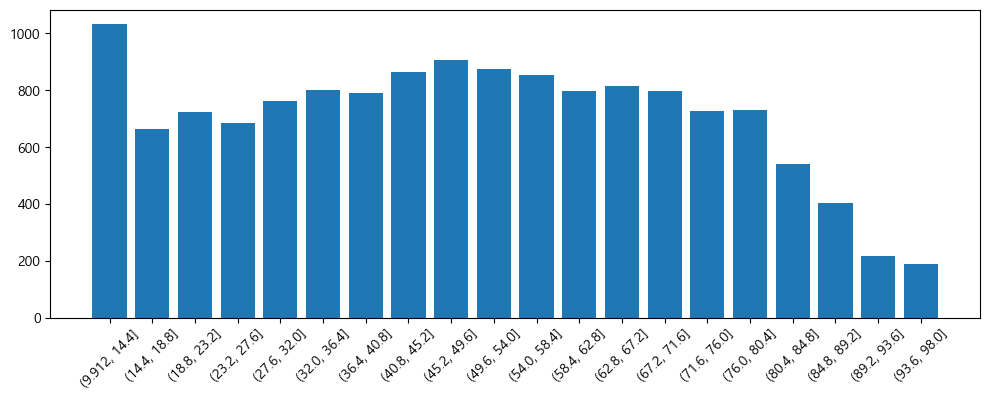

In [680]:
hum_bins=pd.cut(data_train2['Humidity(%)'], bins=20)
hum_mean = data_train2.groupby(hum_bins,observed=True)['Rented Bike Count'].mean()
plt.figure(figsize=(12 ,4))
plt.bar(hum_mean.index.astype(str), hum_mean.values)
plt.xticks(rotation=45)
plt.show()

In [681]:
is_raining = data_train2['Rainfall(mm)'] > 0
high_humidity = data_train2['Humidity(%)'] >= 80
pd.crosstab(high_humidity, is_raining, normalize='index')

Rainfall(mm),False,True
Humidity(%),,
False,0.991812,0.008188
True,0.693042,0.306958


# 예측

In [682]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       720 non-null    object 
 1   Hour                       720 non-null    int64  
 2   Temperature(째C)            644 non-null    float64
 3   Humidity(%)                720 non-null    int64  
 4   Wind speed (m/s)           646 non-null    float64
 5   Visibility (10m)           720 non-null    int64  
 6   Dew point temperature(째C)  720 non-null    float64
 7   Solar Radiation (MJ/m2)    720 non-null    float64
 8   Rainfall(mm)               720 non-null    float64
 9   Snowfall (cm)              720 non-null    float64
 10  Seasons                    646 non-null    object 
 11  Holiday                    720 non-null    object 
 12  Functioning Day            720 non-null    object 
dtypes: float64(6), int64(3), object(4)
memory usage: 7

In [683]:
data_test.describe()

,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,720.000000,644.000000,720.000000,646.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,11.500000,7.717857,57.726389,1.396285,1187.305556,-0.933611,0.368542,0.109861,0.170833
std,6.926999,4.561766,20.613305,0.853039,603.911910,6.701915,0.608023,1.141212,0.845348
min,0.000000,-3.000000,13.000000,0.000000,33.000000,-19.000000,0.000000,0.000000,0.000000
25%,5.750000,4.200000,41.000000,0.800000,627.250000,-5.100000,0.000000,0.000000,0.000000
50%,11.500000,7.400000,57.000000,1.200000,1218.500000,0.200000,0.000000,0.000000,0.000000
75%,17.250000,11.100000,75.000000,1.900000,1788.250000,3.525000,0.525000,0.000000,0.000000
max,23.000000,19.300000,97.000000,5.300000,2000.000000,13.400000,2.220000,18.000000,8.800000


In [684]:
data_test['Functioning Day'].sort_values()

197     No
69      No
68      No
133     No
66      No
      ... 
290    Yes
291    Yes
292    Yes
274    Yes
719    Yes
Name: Functioning Day, Length: 720, dtype: object

In [685]:
data_test[data_test['Functioning Day'] == 'No']

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
48,03/11/2018,0,8.8,63,0.6,1314,2.1,0.0,0.0,0.0,Autumn,No Holiday,No
49,03/11/2018,1,8.5,61,0.2,1273,1.3,0.0,0.0,0.0,Autumn,No Holiday,No
50,03/11/2018,2,NaN,68,1.2,1170,2.0,0.0,0.0,0.0,Autumn,No Holiday,No
51,03/11/2018,3,7.1,67,NaN,1229,1.3,0.0,0.0,0.0,Autumn,No Holiday,No
52,03/11/2018,4,6.3,72,NaN,1104,1.6,0.0,0.0,0.0,Autumn,No Holiday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,09/11/2018,19,11.9,71,2.7,589,6.7,0.0,0.0,0.0,Autumn,No Holiday,No
212,09/11/2018,20,11.9,72,2.5,526,7.0,0.0,0.0,0.0,Autumn,No Holiday,No
213,09/11/2018,21,11.4,74,1.9,498,6.9,0.0,0.0,0.0,Autumn,No Holiday,No
214,09/11/2018,22,11.2,75,NaN,478,6.9,0.0,0.0,0.0,Autumn,No Holiday,No


In [686]:
# Functioning Day가 No인 날들은 대여량이 모두 0임.
# train data에서는 Functioning Day가 No인 날들을 모두 제거한 상태(data_train2)
# 변수들에 의해 0으로 나타나는 것이 아니라 특정 사유에 의해 대여량이 0이 되는 것이므로
# test data에서 Functioning Day가 Yes인 그룹과 No인 그룹으로 분류해서 예측 돌릴 때는 Yes 그룹만 실행

In [687]:
test_yes = data_test[data_test['Functioning Day'] == 'Yes'].copy()
test_no = data_test[data_test['Functioning Day'] == 'No'].copy()

In [688]:
test_yes.head()

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [689]:
test_yes[test_yes['Functioning Day'] == 'No']

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [690]:
test_yes.describe()

,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,648.000000,581.000000,648.000000,581.000000,648.000000,648.000000,648.000000,648.000000,648.000000
mean,11.500000,7.277969,56.844136,1.353701,1222.706790,-1.593981,0.361358,0.092747,0.189815
std,6.927534,4.475007,20.930564,0.790901,604.379757,6.680078,0.600294,0.974970,0.889117
min,0.000000,-3.000000,13.000000,0.000000,33.000000,-19.000000,0.000000,0.000000,0.000000
25%,5.750000,3.800000,40.000000,0.800000,678.750000,-6.100000,0.000000,0.000000,0.000000
50%,11.500000,6.900000,55.000000,1.200000,1295.000000,-0.200000,0.000000,0.000000,0.000000
75%,17.250000,10.600000,74.000000,1.900000,1821.500000,1.725000,0.502500,0.000000,0.000000
max,23.000000,19.300000,97.000000,4.100000,2000.000000,13.400000,2.220000,18.000000,8.800000


In [691]:
data_train2 = pd.get_dummies(data_train2, columns=['Seasons'], dtype=int)

In [692]:
test_yes = pd.get_dummies(test_yes, columns=['Seasons'], dtype=int)

In [693]:
test_yes = test_yes.reindex(columns=data_train2.columns, fill_value=0)

In [701]:
test_yes

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Bad_Weather,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,01/11/2018,0,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
1,01/11/2018,0,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
2,01/11/2018,0,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
3,01/11/2018,0,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
4,01/11/2018,0,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,0,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,0
716,30/11/2018,0,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
717,30/11/2018,0,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
718,30/11/2018,0,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0


In [698]:
data_train2

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Bad_Weather,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,No Holiday,Yes,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7812,2018-10-31,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
7813,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
7814,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0
7815,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,No Holiday,Yes,0,1,0,0,0


In [699]:
test_yes['Bad_Weather'] = ((test_yes['Rainfall(mm)'] > 0) | (test_yes['Snowfall (cm)'] > 3.7)).astype(int)

In [700]:
test_yes['Bad_Weather'].value_counts()

Bad_Weather
0    628
1     20
Name: count, dtype: int64

In [703]:
test_yes['Holiday'].value_counts()

Holiday
No Holiday    648
Name: count, dtype: int64

In [704]:
data_train2['Holiday'] = (data_train2['Holiday'] == 'Yes').astype(int)

In [705]:
test_yes['Holiday'] = (test_yes['Holiday'] == 'Yes').astype(int)

In [706]:
data_train2

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Bad_Weather,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,Yes,0,0,0,0,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,Yes,0,0,0,0,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,Yes,0,0,0,0,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,Yes,0,0,0,0,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,Yes,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7812,2018-10-31,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,0,Yes,0,1,0,0,0
7813,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,0,Yes,0,1,0,0,0
7814,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,0,Yes,0,1,0,0,0
7815,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,0,Yes,0,1,0,0,0


# 모델링

* 랜덤포레스트 사용

In [707]:
X_train = data_train2.drop(columns=['Functioning Day', 'Rented Bike Count', 'Date'])
Y_train = data_train2['Rented Bike Count']

In [711]:
X_test = test_yes.drop(columns=['Functioning Day', 'Rented Bike Count', 'Date'])

In [712]:
X_train

,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Bad_Weather,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,0,0,0,1
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,0,0,0,1
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,0,0,0,1
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,0,0,0,1
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7812,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,0,0,1,0,0,0
7813,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,0,0,1,0,0,0
7814,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,0,0,1,0,0,0
7815,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,0,0,1,0,0,0


In [713]:
X_test

,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Bad_Weather,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,0,0,1,0,0,0
1,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,0,0,1,0,0,0
2,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,0,0,1,0,0,0
3,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,0,0,1,0,0,0
4,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,0,0,0,0,0,0
716,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,0,0,1,0,0,0
717,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,0,0,1,0,0,0
718,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,0,0,1,0,0,0


In [714]:
from sklearn.ensemble import RandomForestRegressor

In [715]:
from sklearn.model_selection import train_test_split

X = data_train2.drop(columns=['Date', 'Functioning Day', 'Rented Bike Count'])

y = data_train2['Rented Bike Count']

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [721]:
model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=6, 
    min_samples_leaf=10, 
    random_state=42
)

model.fit(X_tr, y_tr)

,n_estimators,300
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [722]:
y_tr_pred = model.predict(X_tr)

y_val_pred = model.predict(X_val)

In [723]:
y_tr_pred = model.predict(X_tr)
y_val_pred = model.predict(X_val)

In [725]:
from sklearn.metrics import r2_score, mean_squared_error
print("훈련 R2 점수:", r2_score(y_tr, y_tr_pred))
print("검증(Validation) R2 점수:", r2_score(y_val, y_val_pred))

훈련 R2 점수: 0.8367632885214052
검증(Validation) R2 점수: 0.8149153080323442


In [726]:
print("검증 RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

검증 RMSE: 274.59272798361553


In [727]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_train = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
print("학습 RMSE :", rmse_train)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("검증 RMSE :", rmse_val)

print("학습 MAE  :", mean_absolute_error(y_tr, y_tr_pred))
print("검증 MAE  :", mean_absolute_error(y_val, y_val_pred))

print("학습 R2   :", r2_score(y_tr, y_tr_pred))
print("검증 R2   :", r2_score(y_val, y_val_pred))

학습 RMSE : 266.46307974858837
검증 RMSE : 274.59272798361553
학습 MAE  : 175.94892242455475
검증 MAE  : 180.17397593291793
학습 R2   : 0.8367632885214052
검증 R2   : 0.8149153080323442
